# Reverse or rotate the baroclinic wave test case

## Config: output path

This notebook writes three NetCDF error files. Edit `SAVE_DIR` below if you want them written somewhere else — everything downstream reads/writes through this one variable. By default it resolves to `data/SpeedyWeather/saved_errors/` at the repo root, relative to this notebook's own directory (the default Jupyter/IJulia working directory when a notebook is opened).

In [ ]:
const SAVE_DIR = normpath(joinpath(pwd(), "..", "data", "SpeedyWeather", "saved_errors"))
mkpath(SAVE_DIR);   # trailing ; so the resolved absolute path is not echoed


In [2]:
using SpeedyWeather, CairoMakie, NCDatasets, Dates, OrderedCollections

# Baseline
Original code from

https://speedyweather.github.io/SpeedyWeatherDocumentation/dev/examples_3D#Jablonowski-Williamson-baroclinic-wave

In [3]:
spectral_grid = SpectralGrid(Grid=OctaminimalGaussianGrid,trunc=42, nlayers=8, dealiasing=3, NF=Float64)
orography = EarthOrography(spectral_grid)

land_temperature = LandBucketTemperature(spectral_grid)
soil_moisture = LandBucketMoisture(spectral_grid)
land = LandModel(spectral_grid; temperature=land_temperature, soil_moisture)
ocean = SlabOcean(spectral_grid)

model = PrimitiveDryModel(spectral_grid; orography, land, ocean)
simulation = initialize!(model)
run!(simulation, period=Day(10))

   0%  ETA: 0:00:46 (2000-01-01, 50.65 years/day,  52 m/s, [ -85,   29] ˚C)

   1%  ETA: 0:02:03 (2000-01-01, 19.04 years/day,  57 m/s, [ -94,   29] ˚C)

   2%  ETA: 0:01:13 (2000-01-01, 31.70 years/day,  61 m/s, [ -92,   29] ˚C)

   3%  ETA: 0:00:55 (2000-01-01, 42.04 years/day,  59 m/s, [ -84,   29] ˚C)

   3%  ETA: 0:00:47 (2000-01-01, 48.28 years/day,  56 m/s, [ -81,   29] ˚C)

...

  97%  ETA: 0:00:00 (2000-01-10, 167.96 years/day,  74 m/s, [ -82,   20] ˚C)

  98%  ETA: 0:00:00 (2000-01-10, 168.06 years/day,  74 m/s, [ -82,   20] ˚C)

  99%  ETA: 0:00:00 (2000-01-10, 168.20 years/day,  75 m/s, [ -81,   20] ˚C)

  99%  ETA: 0:00:00 (2000-01-10, 168.33 years/day,  76 m/s, [ -81,   20] ˚C)

 100% Time: 0:00:14 (2000-01-11, 168.42 years/day,  76 m/s, [ -81,   20] ˚C)


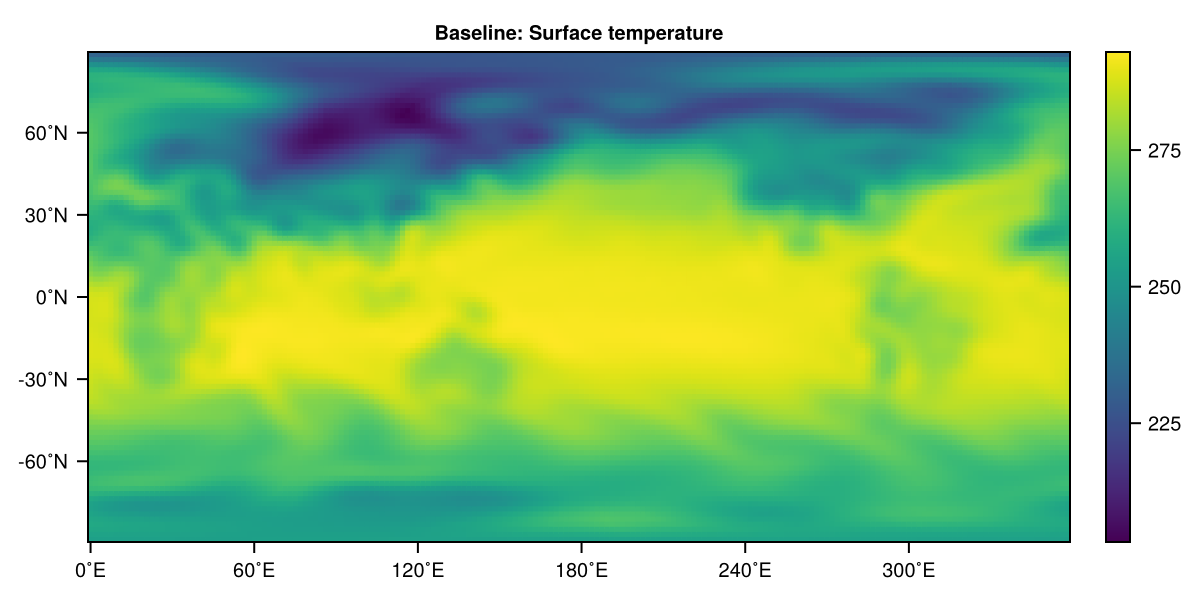

In [4]:
temp = simulation.variables.grid.temperature[:, end]
heatmap(temp, title="Baseline: Surface temperature")

# Identify which variables to rotate/reverse

All the prognostic variables have to be reversed, no memory should reside in the other variable groups

In [5]:
simulation.variables

Variables{@NamedTuple{...}, ...} (19.44 MB)
├ prognostic (1.41 MB)
│ ├ clock: Clock{DateTime, Second, Int64, Millisecond}
│ ├ scale: Base.RefValue{Float64}
│ ├ vorticity: 989×8×2 LowerTriangularArray{ComplexF64, 3, Array{...}}
│ ├ divergence: 989×8×2 LowerTriangularArray{ComplexF64, 3, Array{...}}
│ ├ temperature: 989×8×2 LowerTriangularArray{ComplexF64, 3, Array{...}}
│ ├ pressure: 989×2 LowerTriangularArray{ComplexF64, 2, Array{...}}
│ ├ land
│ │ ├ soil_temperature: 9408×2, 96-ring OctaminimalGaussianField{Float64, 2...
│ │ ├ soil_moisture: 9408×2, 96-ring OctaminimalGaussianField{Float64, 2} a...
│ │ └ snow_depth: 9408-element, 96-ring OctaminimalGaussianField{Float64, 1...
│ └ ocean
│   ├ sea_surface_temperature: 9408-element, 96-ring OctaminimalGaussianFie...
│   └ sea_ice_concentration: 9408-element, 96-ring OctaminimalGaussianField...
├ grid (6.25 MB)
│ ├ vorticity: 9408×8, 96-ring OctaminimalGaussianField{Float64, 2} as Arra...
│ ├ u: 9408×8, 96-ring OctaminimalGaussianField{Fl

# Rotate longitude

Start creating another (at first identical) model and simulation

In [6]:
spectral_grid = SpectralGrid(Grid=OctaminimalGaussianGrid,trunc=42, nlayers=8, dealiasing=3, NF=Float64)
orography = EarthOrography(spectral_grid)

land_temperature = LandBucketTemperature(spectral_grid)
soil_moisture = LandBucketMoisture(spectral_grid)
land = LandModel(spectral_grid; temperature=land_temperature, soil_moisture)
ocean = SlabOcean(spectral_grid)

# but rename model and simulation to avoid overwriting
model_rotate_lon = PrimitiveDryModel(spectral_grid; orography=deepcopy(orography), land=deepcopy(land), ocean=deepcopy(ocean))
simulation_rotate_lon = initialize!(model_rotate_lon)

Simulation{...} (23.08 MB)
├ variables::Variables{...} (19.44 MB)
└ model::PrimitiveDryModel{...} (4.92 MB)

In [7]:
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))

    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)

    λ = 0
    # rotate longitude by π: shift solar hour angle by half a day
    solar_hour_angle_0E = SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc + NF(π)

    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)

    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end

In [8]:
# rotate variables
(; variables) = simulation_rotate_lon
(; vorticity, divergence, temperature, pressure) = variables.prognostic
(; land, ocean) = variables.prognostic

for k in eachmatrix(vorticity)
    SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(vorticity, :, k), 180)
    SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(divergence, :, k), 180)
    SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(temperature, :, k), 180)
end

for k in eachmatrix(pressure)
    SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(pressure, :, k), 180)
end

# rotate land prognostic variables
SpeedyWeather.rotate!(land.soil_temperature, 180)
SpeedyWeather.rotate!(land.soil_moisture, 180)
SpeedyWeather.rotate!(land.snow_depth, 180)

# rotate ocean prognostic variables
SpeedyWeather.rotate!(ocean.sea_surface_temperature, 180)
SpeedyWeather.rotate!(ocean.sea_ice_concentration, 180);

In [9]:
# rotate boundary conditions
SpeedyWeather.rotate!(simulation_rotate_lon.model.land_sea_mask.mask, 180)
SpeedyWeather.rotate!(simulation_rotate_lon.model.orography.surface_geopotential, 180)
SpeedyWeather.rotate!(simulation_rotate_lon.model.orography.orography, 180)

SpeedyWeather.rotate!(simulation_rotate_lon.model.land.vegetation.high_cover, 180)
SpeedyWeather.rotate!(simulation_rotate_lon.model.land.vegetation.low_cover, 180);

In [10]:
simulation_rotate_lon.model

PrimitiveDryModel{...} <: PrimitiveDry (4.92 MB)
├ spectral_grid::SpectralGrid{CPU{KernelAbstractions.CPU}, Spectrum{CPU{Ker...
├ architecture::CPU{KernelAbstractions.CPU}
├ dynamics::Bool
├ geometry::Geometry{SpectralGrid{CPU{KernelAbstractions.CPU}, Spectrum{CPU...
├ planet::Earth{Float64, Second, DateTime, Bool}
├ atmosphere::EarthDryAtmosphere{Float64}
├ coriolis::Coriolis{Vector{Float64}}
├ geopotential::Geopotential{Vector{Float64}}
├ adiabatic_conversion::AdiabaticConversion{Vector{Float64}}
├ particle_advection::Nothing
├ initial_conditions::@NamedTuple{vordiv::ZonalWind{Float64}, pres::Pressur...
├ forcing::Nothing
├ drag::SpeedLimitDrag{Float64}
├ random_process::Nothing
├ tracers::Dict{Symbol, Tracer}
├ dynamics_only::Bool
├ orography::EarthOrography{Float64, Field{Float64, 1, Vector{Float64}, Oct...
├ land_sea_mask::EarthLandSeaMask{Float64, Field{Float64, 1, Vector{Float64...
├ ocean::SlabOcean{Float64}
├ sea_ice::ThermodynamicSeaIce{Float64}
├ land::LandModel{LandGeometry

   1%  ETA: 0:00:17 (2000-01-01, 142.01 years/day,  53 m/s, [ -87,   29] ˚C)

   1%  ETA: 0:00:14 (2000-01-01, 162.87 years/day,  57 m/s, [ -94,   29] ˚C)

   2%  ETA: 0:00:14 (2000-01-01, 170.47 years/day,  61 m/s, [ -92,   29] ˚C)

   3%  ETA: 0:00:13 (2000-01-01, 173.88 years/day,  59 m/s, [ -84,   29] ˚C)

   4%  ETA: 0:00:13 (2000-01-01, 176.07 years/day,  55 m/s, [ -81,   28] ˚C)

...

  97%  ETA: 0:00:00 (2000-01-10, 184.97 years/day,  74 m/s, [ -82,   20] ˚C)

  97%  ETA: 0:00:00 (2000-01-10, 184.86 years/day,  74 m/s, [ -82,   20] ˚C)

  98%  ETA: 0:00:00 (2000-01-10, 184.87 years/day,  75 m/s, [ -81,   20] ˚C)

  99%  ETA: 0:00:00 (2000-01-10, 184.89 years/day,  76 m/s, [ -81,   20] ˚C)

 100% Time: 0:00:12 (2000-01-11, 184.91 years/day,  76 m/s, [ -81,   20] ˚C)

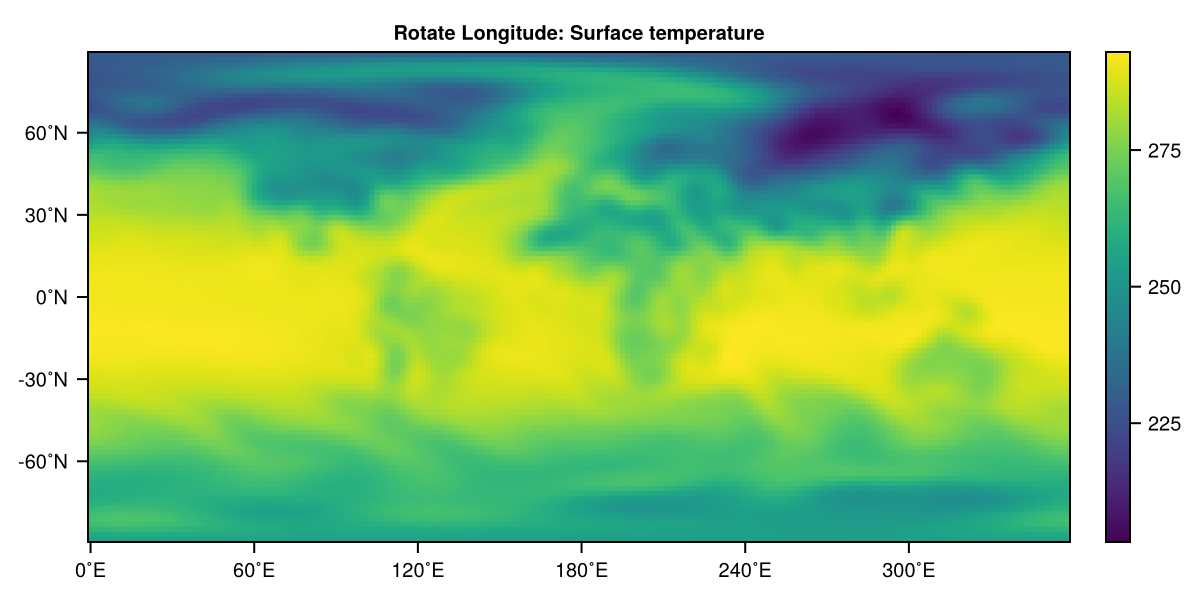

In [11]:
run!(simulation_rotate_lon, period=Day(10))

temp_rot_lon = simulation_rotate_lon.variables.grid.temperature[:, end]
heatmap(temp_rot_lon, title="Rotate Longitude: Surface temperature")

## Error map

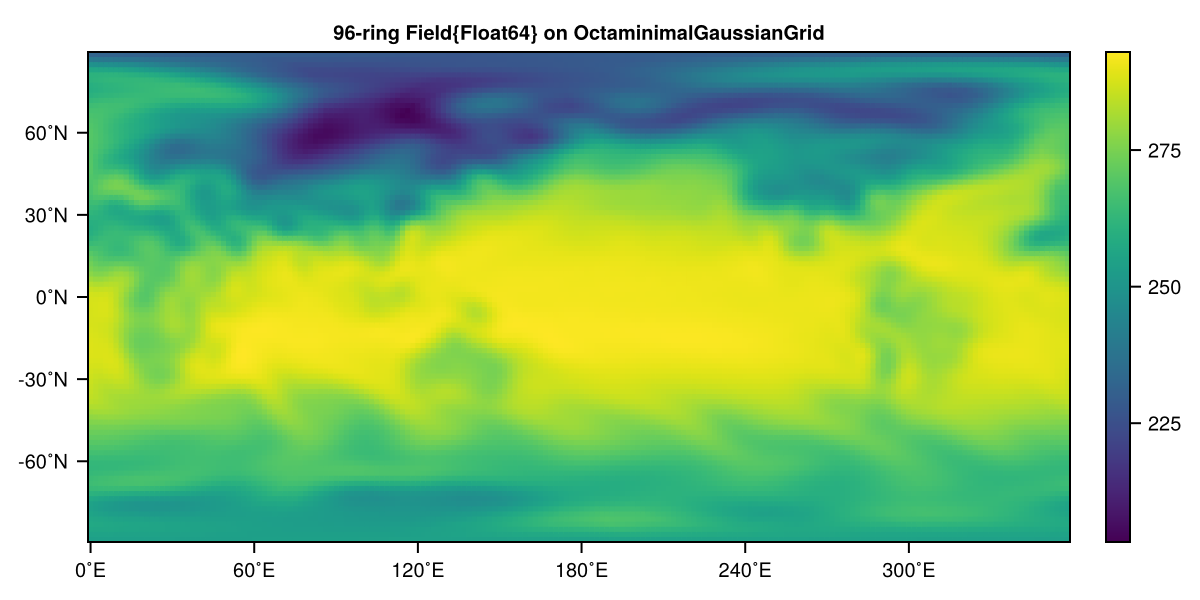

In [12]:
temp_rotated_back = SpeedyWeather.rotate!(deepcopy(temp_rot_lon), -180)
heatmap(temp_rotated_back)

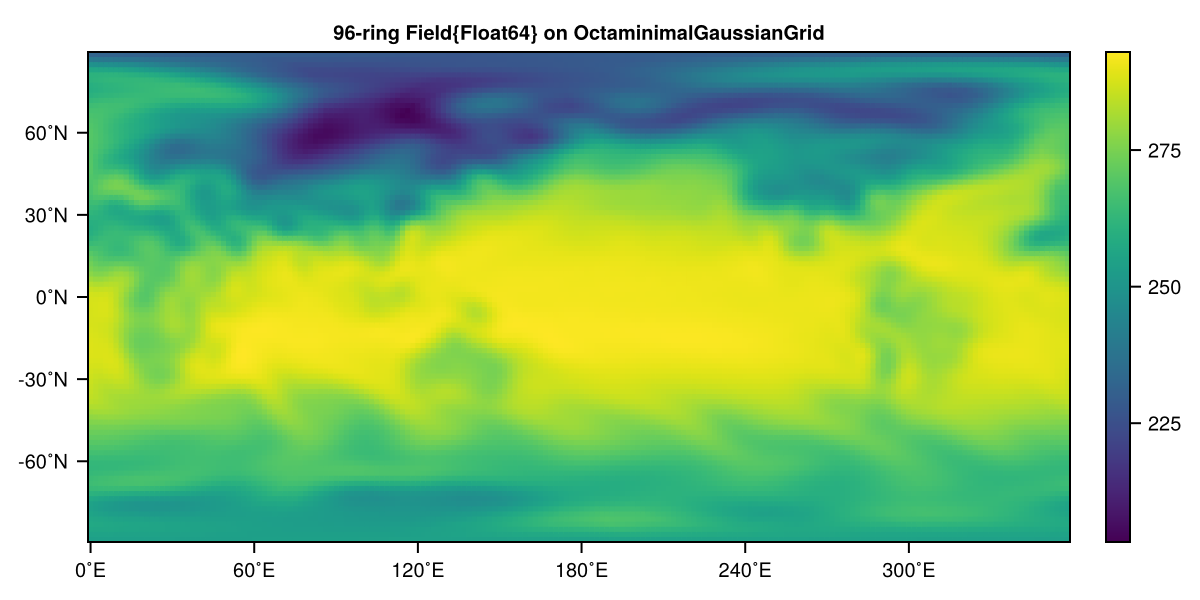

In [13]:
heatmap(temp)

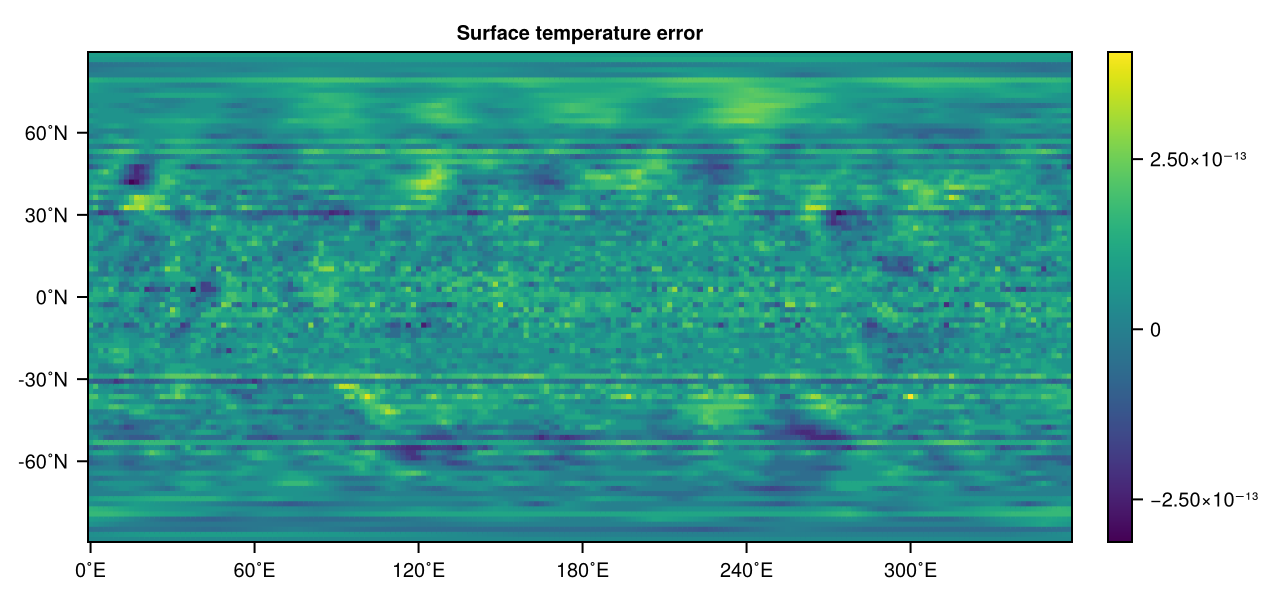

In [14]:
heatmap(temp_rotated_back - temp, title="Surface temperature error")

# Reverse latitude

In [15]:
spectral_grid = SpectralGrid(Grid=OctaminimalGaussianGrid,trunc=42, nlayers=8, dealiasing=3, NF=Float64)
orography = EarthOrography(spectral_grid)

land_temperature = LandBucketTemperature(spectral_grid)
soil_moisture = LandBucketMoisture(spectral_grid)
land = LandModel(spectral_grid; temperature=land_temperature, soil_moisture)
ocean = SlabOcean(spectral_grid)

# but rename model and simulation to avoid overwriting
model_reverse_lat = PrimitiveDryModel(spectral_grid; orography=deepcopy(orography), land=deepcopy(land), ocean=deepcopy(ocean))
simulation_reverse_lat = initialize!(model_reverse_lat)

Simulation{...} (23.08 MB)
├ variables::Variables{...} (19.44 MB)
└ model::PrimitiveDryModel{...} (4.92 MB)

In [16]:
# reverse variables
(; variables) = simulation_reverse_lat
(; vorticity, divergence, temperature, pressure) = variables.prognostic
(; land, ocean) = variables.prognostic

for k in eachmatrix(vorticity)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(vorticity, :, k), dims=:lat)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(divergence, :, k), dims=:lat)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(temperature, :, k), dims=:lat)
end

# and as v -> -v, y -> -y also vorticity ζ -> -ζ
vorticity .*= -1

for k in eachmatrix(pressure)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(pressure, :, k), dims=:lat)
end

# reverse land prognostic variables
SpeedyWeather.reverse!(land.soil_temperature, dims=:lat)
SpeedyWeather.reverse!(land.soil_moisture, dims=:lat)
SpeedyWeather.reverse!(land.snow_depth, dims=:lat)

# reverse ocean prognostic variables
SpeedyWeather.reverse!(ocean.sea_surface_temperature, dims=:lat)
SpeedyWeather.reverse!(ocean.sea_ice_concentration, dims=:lat);

In [17]:
# reverse boundary conditions
SpeedyWeather.reverse!(simulation_reverse_lat.model.land_sea_mask.mask, dims=:lat)
SpeedyWeather.reverse!(simulation_reverse_lat.model.orography.surface_geopotential, dims=:lat)
SpeedyWeather.reverse!(simulation_reverse_lat.model.orography.orography, dims=:lat);

SpeedyWeather.reverse!(simulation_reverse_lat.model.land.vegetation.high_cover, dims=:lat)
SpeedyWeather.reverse!(simulation_reverse_lat.model.land.vegetation.low_cover, dims=:lat);

In [18]:
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},      # ← AbstractField, not AbstractGrid
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))

    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)

    λ = 0
    solar_hour_angle_0E = SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc

    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)

    # reverse latitude: negate sinlat only (cos(-φ) = cos(φ))
    sinlat_rev = -sinlat

    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat_rev, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end


   1%  ETA: 0:00:13 (2000-01-01, 186.74 years/day,  55 m/s, [ -92,   29] ˚C)

   2%  ETA: 0:00:12 (2000-01-01, 187.44 years/day,  57 m/s, [ -94,   29] ˚C)

   3%  ETA: 0:00:18 (2000-01-01, 125.82 years/day,  61 m/s, [ -92,   29] ˚C)

   4%  ETA: 0:00:16 (2000-01-01, 140.60 years/day,  55 m/s, [ -81,   28] ˚C)

   4%  ETA: 0:00:28 (2000-01-01, 81.86 years/day,  52 m/s, [ -81,   28] ˚C)

...

  97%  ETA: 0:00:00 (2000-01-10, 173.96 years/day,  74 m/s, [ -82,   20] ˚C)

  98%  ETA: 0:00:00 (2000-01-10, 174.02 years/day,  74 m/s, [ -82,   20] ˚C)

  99%  ETA: 0:00:00 (2000-01-10, 174.11 years/day,  75 m/s, [ -81,   20] ˚C)

  99%  ETA: 0:00:00 (2000-01-10, 174.17 years/day,  76 m/s, [ -81,   20] ˚C)

 100% Time: 0:00:13 (2000-01-11, 174.19 years/day,  76 m/s, [ -81,   20] ˚C)


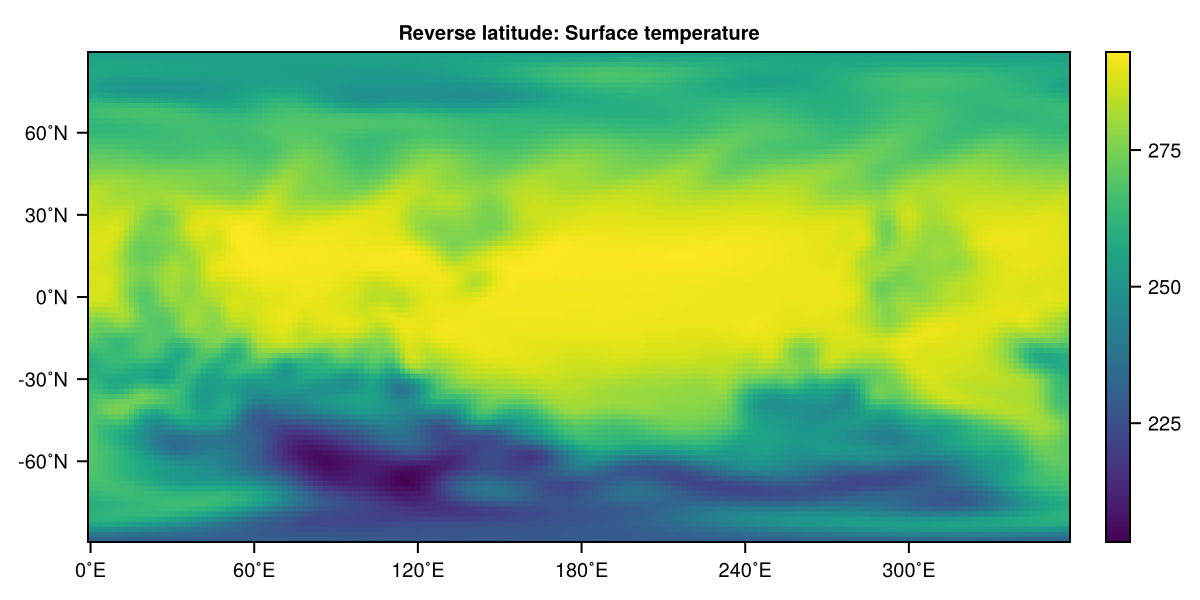

In [19]:
# run and visualise
run!(simulation_reverse_lat, period=Day(10))

temp_rev_lat = simulation_reverse_lat.variables.grid.temperature[:, end]
heatmap(temp_rev_lat, title="Reverse latitude: Surface temperature")

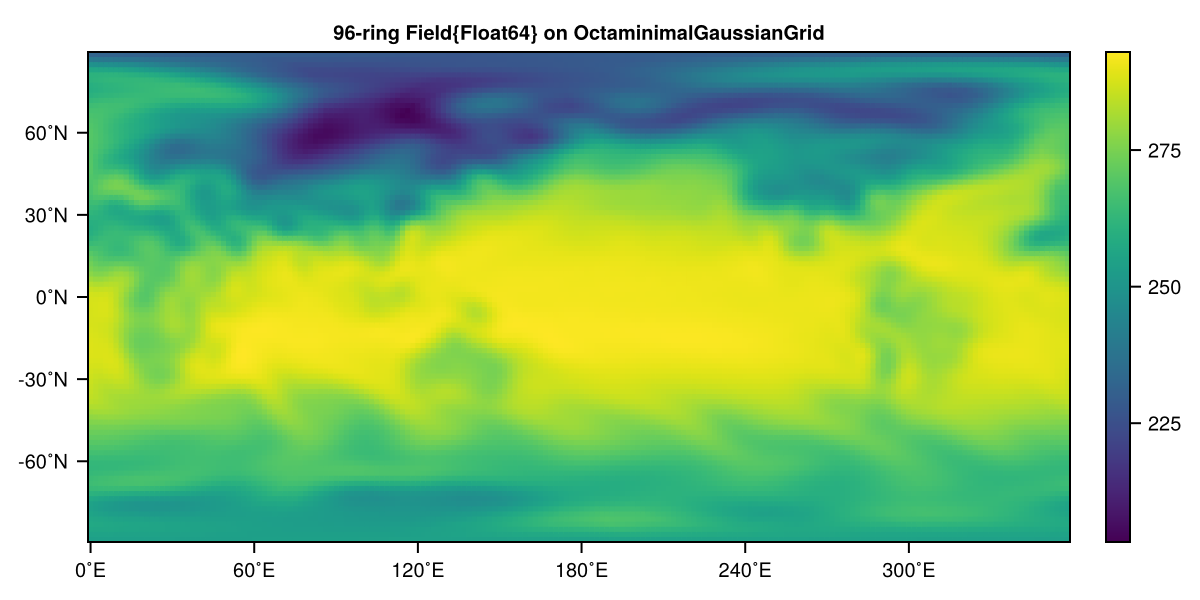

In [20]:
temp_reversed_lat_back = reverse!(deepcopy(temp_rev_lat), dims=:lat)
heatmap(temp_reversed_lat_back)

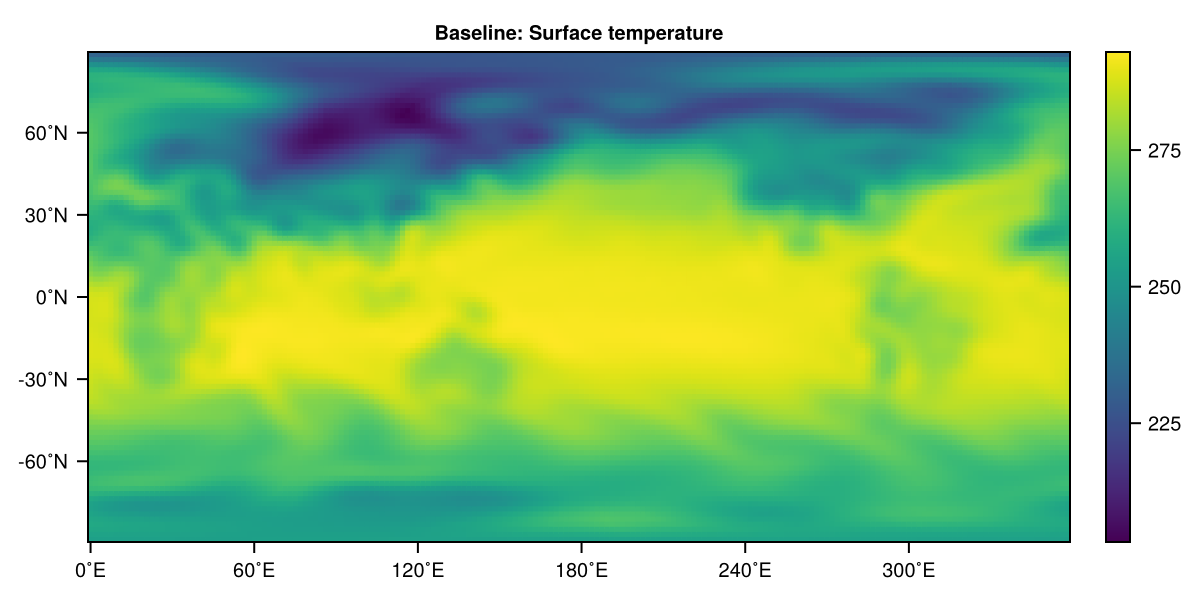

In [21]:
heatmap(temp, title="Baseline: Surface temperature")

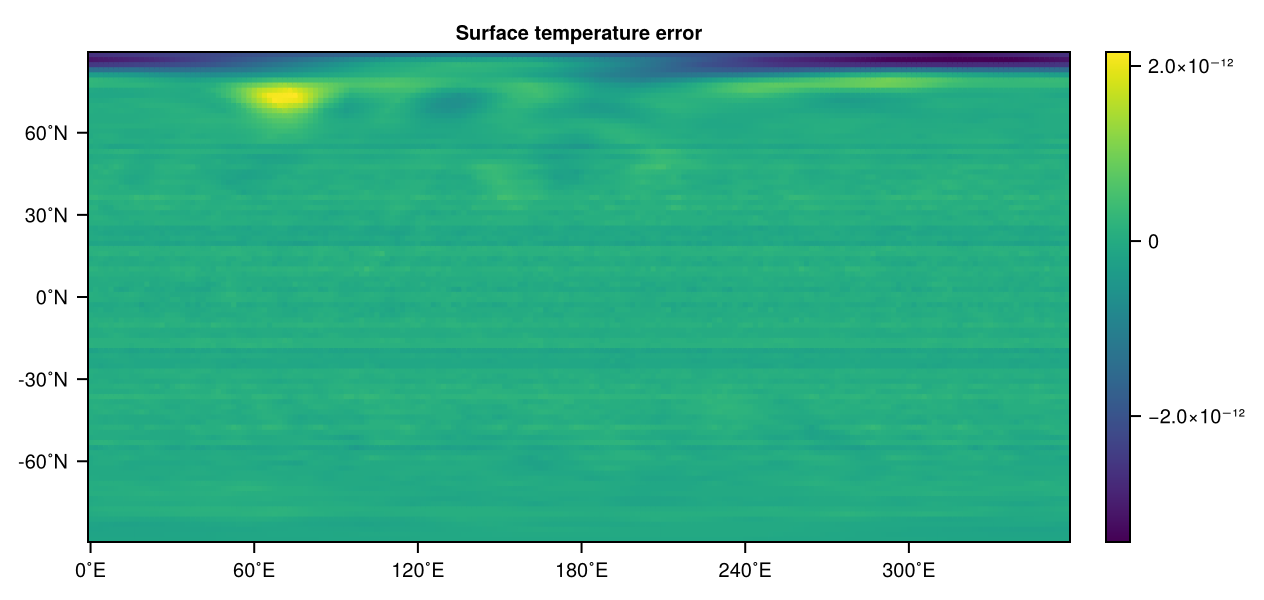

In [22]:
heatmap(temp_reversed_lat_back - temp, title="Surface temperature error")

# Reverse longitude

In [23]:
spectral_grid = SpectralGrid(Grid=OctaminimalGaussianGrid,trunc=42, nlayers=8, dealiasing=3, NF=Float64)
orography = EarthOrography(spectral_grid)

land_temperature = LandBucketTemperature(spectral_grid)
soil_moisture = LandBucketMoisture(spectral_grid)
land = LandModel(spectral_grid; temperature=land_temperature, soil_moisture)
ocean = SlabOcean(spectral_grid)

# but rename model and simulation to avoid overwriting
model_reverse_lon = PrimitiveDryModel(spectral_grid; orography=deepcopy(orography), land=deepcopy(land), ocean=deepcopy(ocean))
simulation_reverse_lon = initialize!(model_reverse_lon)

Simulation{...} (23.08 MB)
├ variables::Variables{...} (19.44 MB)
└ model::PrimitiveDryModel{...} (4.92 MB)

In [24]:
# reverse variables
(; variables) = simulation_reverse_lon
(; vorticity, divergence, temperature, pressure) = variables.prognostic
(; land, ocean) = variables.prognostic

for k in eachmatrix(vorticity)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(vorticity, :, k), dims=:lon)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(divergence, :, k), dims=:lon)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(temperature, :, k), dims=:lon)
end

# and as u -> -u, x -> -x also vorticity ζ -> -ζ, divergence remains unchanged
vorticity .*= -1

for k in eachmatrix(pressure)
    SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(pressure, :, k), dims=:lon)
end

# reverse land prognostic variables
SpeedyWeather.reverse!(land.soil_temperature, dims=:lon)
SpeedyWeather.reverse!(land.soil_moisture, dims=:lon)
SpeedyWeather.reverse!(land.snow_depth, dims=:lon)

# reverse ocean prognostic variables
SpeedyWeather.reverse!(ocean.sea_surface_temperature, dims=:lon)
SpeedyWeather.reverse!(ocean.sea_ice_concentration, dims=:lon);

In [25]:
# reverse boundary conditions
SpeedyWeather.reverse!(simulation_reverse_lon.model.land_sea_mask.mask, dims=:lon)
SpeedyWeather.reverse!(simulation_reverse_lon.model.orography.surface_geopotential, dims=:lon)
SpeedyWeather.reverse!(simulation_reverse_lon.model.orography.orography, dims=:lon)

# change the coriolis parameter directly instead of model.planet.rotation
# as ZonalRidge depends on that which however we do not want to change sign!
simulation_reverse_lon.model.coriolis.f .*= -1;

SpeedyWeather.reverse!(simulation_reverse_lon.model.land.vegetation.high_cover, dims=:lon)
SpeedyWeather.reverse!(simulation_reverse_lon.model.land.vegetation.low_cover, dims=:lon);

In [26]:
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))

    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)

    λ = 0
    # reverse longitude λ → -λ: negate solar hour angle
    solar_hour_angle_0E = -(SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc)

    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)

    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end


   1%  ETA: 0:00:19 (2000-01-01, 124.44 years/day,  53 m/s, [ -87,   29] ˚C)

   1%  ETA: 0:00:15 (2000-01-01, 154.99 years/day,  57 m/s, [ -94,   29] ˚C)

   2%  ETA: 0:00:15 (2000-01-01, 151.12 years/day,  61 m/s, [ -92,   29] ˚C)

   3%  ETA: 0:00:14 (2000-01-01, 160.77 years/day,  59 m/s, [ -84,   29] ˚C)

   4%  ETA: 0:00:14 (2000-01-01, 165.03 years/day,  55 m/s, [ -81,   28] ˚C)

...

  97%  ETA: 0:00:00 (2000-01-10, 182.50 years/day,  74 m/s, [ -82,   20] ˚C)

  97%  ETA: 0:00:00 (2000-01-10, 182.51 years/day,  74 m/s, [ -82,   20] ˚C)

  98%  ETA: 0:00:00 (2000-01-10, 182.53 years/day,  75 m/s, [ -81,   20] ˚C)

  99%  ETA: 0:00:00 (2000-01-10, 182.59 years/day,  76 m/s, [ -81,   20] ˚C)

 100% Time: 0:00:12 (2000-01-11, 182.59 years/day,  76 m/s, [ -81,   20] ˚C)

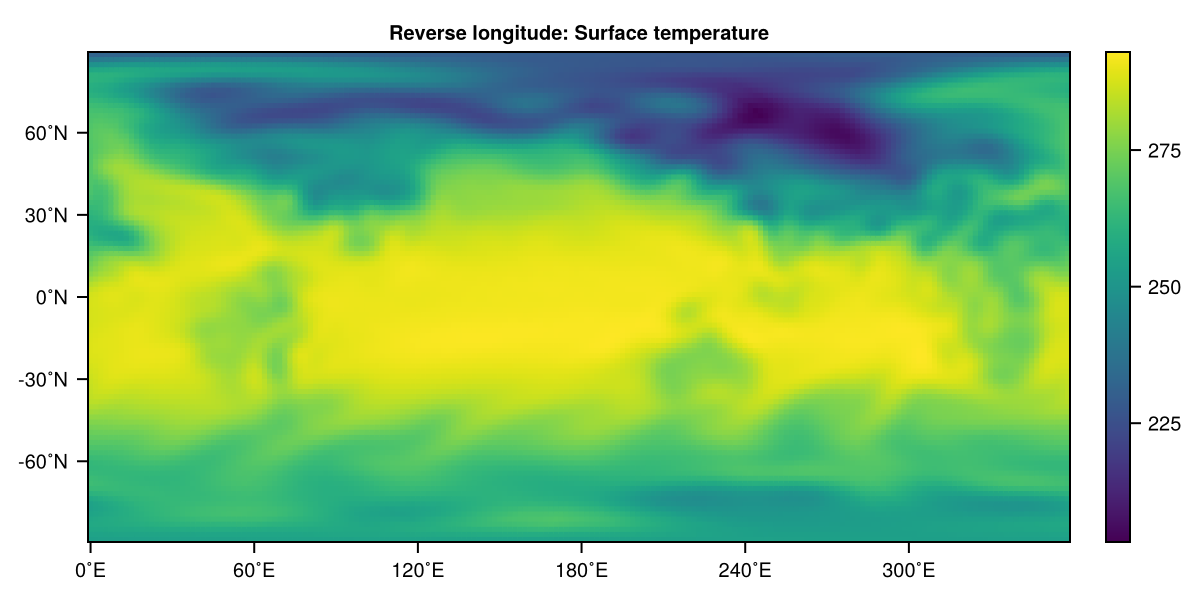

In [27]:
# run and visualise
run!(simulation_reverse_lon, period=Day(10))

temp_rev_lon = simulation_reverse_lon.variables.grid.temperature[:, end]
heatmap(temp_rev_lon, title="Reverse longitude: Surface temperature")

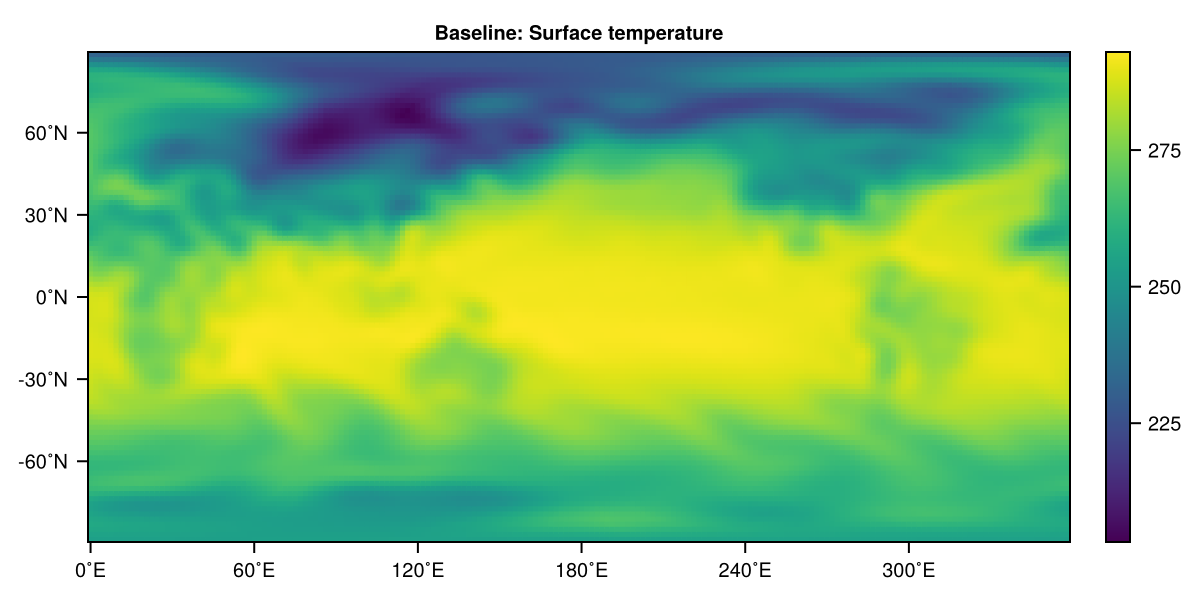

In [28]:
heatmap(temp, title="Baseline: Surface temperature")

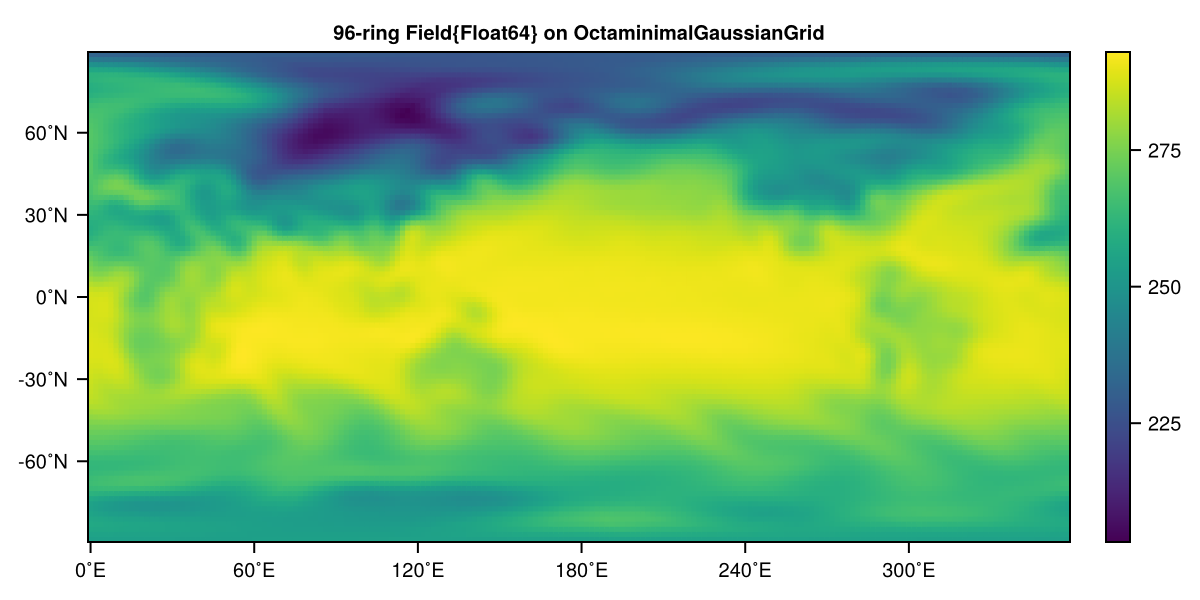

In [29]:
temp_reversed_lon_back = reverse!(deepcopy(temp_rev_lon), dims=:lon)
heatmap(temp_reversed_lon_back)

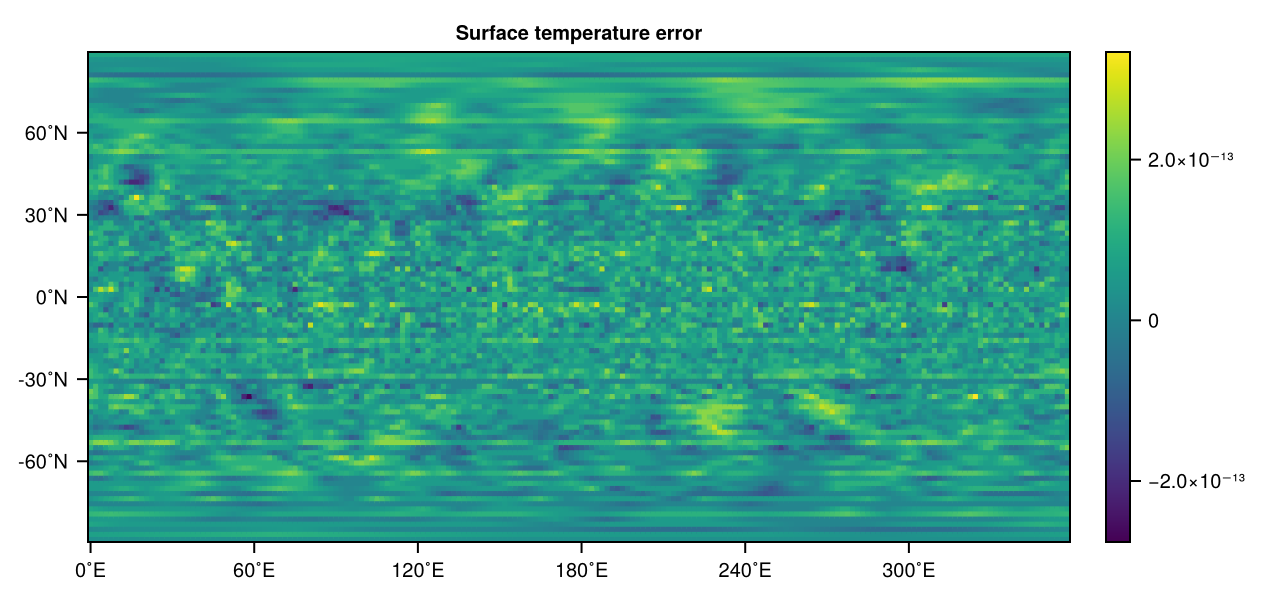

In [30]:
heatmap(temp_reversed_lon_back - temp, title="Surface temperature error")

# Save surface temperature error at each 6h timestep

Each test case is re-run from scratch (40 steps × 6 h = 10 days).  
At every step the surface temperature is captured, inverse-transformed, and compared to the corresponding baseline snapshot.  
Results are saved as `error_matrix` (shape: ngrid × 40, Float64) and `TIMES_H` (hours since start).

In [31]:
"""Run simulation in 6-hourly steps, returning a Vector of surface temperature fields."""
function capture_surface_temp_6h(sim, n_days::Int=10)
    n_steps = n_days * 4
    temps = Vector{Any}(undef, n_steps)
    for i in 1:n_steps
        run!(sim, period=Hour(6))
        temps[i] = deepcopy(sim.variables.grid.temperature[:, end])
    end
    return temps
end

"""Save error_matrix (ngrid × ntimes) and times_h to a NetCDF file."""
function save_error_nc(path, error_matrix, times_h)
    ngrid, nt = size(error_matrix)
    ds = Dataset(path, "c")
    defDim(ds, "gridpoint", ngrid)
    defDim(ds, "time", nt)
    v_t = defVar(ds, "time", Float64, ("time",),
        attrib = OrderedDict("units" => "hours since model start", "long_name" => "forecast time"))
    v_t[:] = times_h
    v_e = defVar(ds, "temperature_error", Float64, ("gridpoint", "time"),
        attrib = OrderedDict("units" => "K",
            "long_name" => "surface temperature error (inverse-transformed minus baseline)"))
    v_e[:, :] = error_matrix
    close(ds)
end

# SAVE_DIR is defined in the config cell at the top of this notebook
const TIMES_H = Float64.(6:6:240)  # hours since start: 6, 12, …, 240

40-element Vector{Float64}:
   6.0
  12.0
  18.0
  24.0
  30.0
  36.0
  42.0
  48.0
  54.0
  60.0
  66.0
  72.0
  78.0
  84.0
  90.0
  96.0
 102.0
 108.0
 114.0
 120.0
 126.0
 132.0
 138.0
 144.0
 150.0
 156.0
 162.0
 168.0
 174.0
 180.0
 186.0
 192.0
 198.0
 204.0
 210.0
 216.0
 222.0
 228.0
 234.0
 240.0

In [32]:
# Restore default cos_zenith! (no coordinate transformation) for the baseline re-run
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))
    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)
    λ = 0
    solar_hour_angle_0E = SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc
    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)
    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end

# Re-initialize and re-run baseline, capturing surface temperature every 6h
let
    sg = SpectralGrid(Grid=OctaminimalGaussianGrid, trunc=42, nlayers=8, dealiasing=3, NF=Float64)
    oro = EarthOrography(sg)
    lnd = LandModel(sg; temperature=LandBucketTemperature(sg), soil_moisture=LandBucketMoisture(sg))
    ocn = SlabOcean(sg)
    mdl = PrimitiveDryModel(sg; orography=oro, land=lnd, ocean=ocn)
    sim = initialize!(mdl)
    global baseline_temps_6h = capture_surface_temp_6h(sim)
end
println("Baseline: $(length(baseline_temps_6h)) snapshots captured")

  36%  ETA: 0:00:00 (2000-01-01, 186.55 years/day,  55 m/s, [ -92,   29] ˚C)

  73%  ETA: 0:00:00 (2000-01-01, 151.88 years/day,  57 m/s, [ -94,   29] ˚C)

 100% Time: 0:00:00 (2000-01-01, 161.14 years/day,  60 m/s, [ -91,   29] ˚C)


  27%  ETA: 0:00:01 (2000-01-01, 63.54 years/day,  57 m/s, [ -80,   29] ˚C)

  64%  ETA: 0:00:00 (2000-01-01, 102.79 years/day,  55 m/s, [ -81,   28] ˚C)

...

 100% Time: 0:00:00 (2000-01-10, 184.30 years/day,  68 m/s, [ -80,   20] ˚C)


  36%  ETA: 0:00:00 (2000-01-10, 182.62 years/day,  68 m/s, [ -79,   20] ˚C)

  73%  ETA: 0:00:00 (2000-01-10, 183.58 years/day,  68 m/s, [ -79,   20] ˚C)

 100% Time: 0:00:00 (2000-01-11, 184.61 years/day,  69 m/s, [ -79,   20] ˚C)


Baseline: 40 snapshots captured


## Output: this notebook saves data, not figures

The cells below write `error_rotate_lon.nc`, `error_reverse_lat.nc` and
`error_reverse_lon.nc` to `SAVE_DIR` (see the Config cell at the top). The plots in
this notebook, including the final summary line plot, are shown inline only and are
not written to disk.

Those three files feed two of the paper's figures, both produced by
`../GraphCast/plot_forecast_errors.ipynb`:
`graphcast_rmse_vs_leadtime.jpeg`
and `speedyweather_rmse_vs_leadtime.jpeg`. The published version of the second one
is re-plotted from the original run's files by
`reproduce_published_figure/plot_published_figure.ipynb` -- see the note at the
end of this notebook for why the published figure uses those files rather than
freshly generated ones.

In [33]:
# Override cos_zenith! for rotate-longitude (shift solar hour angle by π)
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))
    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)
    λ = 0
    solar_hour_angle_0E = SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc + NF(π)
    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)
    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end

let
    sg = SpectralGrid(Grid=OctaminimalGaussianGrid, trunc=42, nlayers=8, dealiasing=3, NF=Float64)
    oro = EarthOrography(sg)
    lnd = LandModel(sg; temperature=LandBucketTemperature(sg), soil_moisture=LandBucketMoisture(sg))
    ocn = SlabOcean(sg)
    mdl = PrimitiveDryModel(sg; orography=deepcopy(oro), land=deepcopy(lnd), ocean=deepcopy(ocn))
    sim = initialize!(mdl)

    (; vorticity, divergence, temperature, pressure) = sim.variables.prognostic
    (; land, ocean) = sim.variables.prognostic
    for k in eachmatrix(vorticity)
        SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(vorticity, :, k), 180)
        SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(divergence, :, k), 180)
        SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(temperature, :, k), 180)
    end
    for k in eachmatrix(pressure)
        SpeedyWeather.rotate!(LowerTriangularArrays.lta_view(pressure, :, k), 180)
    end
    SpeedyWeather.rotate!(land.soil_temperature, 180)
    SpeedyWeather.rotate!(land.soil_moisture, 180)
    SpeedyWeather.rotate!(land.snow_depth, 180)
    SpeedyWeather.rotate!(ocean.sea_surface_temperature, 180)
    SpeedyWeather.rotate!(ocean.sea_ice_concentration, 180)
    SpeedyWeather.rotate!(mdl.land_sea_mask.mask, 180)
    SpeedyWeather.rotate!(mdl.orography.surface_geopotential, 180)
    SpeedyWeather.rotate!(mdl.orography.orography, 180)
    SpeedyWeather.rotate!(mdl.land.vegetation.high_cover, 180)
    SpeedyWeather.rotate!(mdl.land.vegetation.low_cover, 180)

    temps = capture_surface_temp_6h(sim)

    ngrid, n_steps = length(baseline_temps_6h[1]), length(temps)
    error_matrix = Matrix{Float64}(undef, ngrid, n_steps)
    for i in 1:n_steps
        temp_back = SpeedyWeather.rotate!(deepcopy(temps[i]), -180)
        error_matrix[:, i] = Array(temp_back - baseline_temps_6h[i])
    end

    save_error_nc(joinpath(SAVE_DIR, "error_rotate_lon.nc"), error_matrix, TIMES_H)
    println("Saved error_rotate_lon.nc: $(size(error_matrix))")
end

  36%  ETA: 0:00:00 (2000-01-01, 187.37 years/day,  55 m/s, [ -92,   29] ˚C)

  73%  ETA: 0:00:00 (2000-01-01, 183.57 years/day,  57 m/s, [ -94,   29] ˚C)

 100% Time: 0:00:00 (2000-01-01, 185.76 years/day,  61 m/s, [ -92,   29] ˚C)


  36%  ETA: 0:00:00 (2000-01-01, 182.72 years/day,  56 m/s, [ -81,   29] ˚C)

  73%  ETA: 0:00:00 (2000-01-01, 183.74 years/day,  53 m/s, [ -81,   28] ˚C)

...

  36%  ETA: 0:00:00 (2000-01-10, 188.39 years/day,  68 m/s, [ -79,   20] ˚C)

  73%  ETA: 0:00:00 (2000-01-10, 186.55 years/day,  68 m/s, [ -79,   20] ˚C)

 100% Time: 0:00:00 (2000-01-11, 186.87 years/day,  69 m/s, [ -79,   20] ˚C)


┌ Warning: cannot parse time units `hours since model start`: ArgumentError: invalid base 10 digit 'm' in "model"
└ @ CommonDataModel ~/.julia/packages/CommonDataModel/WcahY/src/cfvariable.jl:147


Saved error_rotate_lon.nc: (9408, 40)


In [34]:
# Override cos_zenith! for reverse-latitude (negate sinlat: φ → -φ)
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))
    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)
    λ = 0
    solar_hour_angle_0E = SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc
    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)
    sinlat_rev = -sinlat
    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat_rev, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end

let
    sg = SpectralGrid(Grid=OctaminimalGaussianGrid, trunc=42, nlayers=8, dealiasing=3, NF=Float64)
    oro = EarthOrography(sg)
    lnd = LandModel(sg; temperature=LandBucketTemperature(sg), soil_moisture=LandBucketMoisture(sg))
    ocn = SlabOcean(sg)
    mdl = PrimitiveDryModel(sg; orography=deepcopy(oro), land=deepcopy(lnd), ocean=deepcopy(ocn))
    sim = initialize!(mdl)

    (; vorticity, divergence, temperature, pressure) = sim.variables.prognostic
    (; land, ocean) = sim.variables.prognostic
    for k in eachmatrix(vorticity)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(vorticity, :, k), dims=:lat)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(divergence, :, k), dims=:lat)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(temperature, :, k), dims=:lat)
    end
    vorticity .*= -1
    for k in eachmatrix(pressure)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(pressure, :, k), dims=:lat)
    end
    SpeedyWeather.reverse!(land.soil_temperature, dims=:lat)
    SpeedyWeather.reverse!(land.soil_moisture, dims=:lat)
    SpeedyWeather.reverse!(land.snow_depth, dims=:lat)
    SpeedyWeather.reverse!(ocean.sea_surface_temperature, dims=:lat)
    SpeedyWeather.reverse!(ocean.sea_ice_concentration, dims=:lat)
    SpeedyWeather.reverse!(mdl.land_sea_mask.mask, dims=:lat)
    SpeedyWeather.reverse!(mdl.orography.surface_geopotential, dims=:lat)
    SpeedyWeather.reverse!(mdl.orography.orography, dims=:lat)
    SpeedyWeather.reverse!(mdl.land.vegetation.high_cover, dims=:lat)
    SpeedyWeather.reverse!(mdl.land.vegetation.low_cover, dims=:lat)

    temps = capture_surface_temp_6h(sim)

    ngrid, n_steps = length(baseline_temps_6h[1]), length(temps)
    error_matrix = Matrix{Float64}(undef, ngrid, n_steps)
    for i in 1:n_steps
        temp_back = reverse!(deepcopy(temps[i]), dims=:lat)
        error_matrix[:, i] = Array(temp_back - baseline_temps_6h[i])
    end

    save_error_nc(joinpath(SAVE_DIR, "error_reverse_lat.nc"), error_matrix, TIMES_H)
    println("Saved error_reverse_lat.nc: $(size(error_matrix))")
end

  27%  ETA: 0:00:00 (2000-01-01, 128.35 years/day,  53 m/s, [ -87,   29] ˚C)

  64%  ETA: 0:00:00 (2000-01-01, 156.39 years/day,  57 m/s, [ -94,   29] ˚C)

 100% Time: 0:00:00 (2000-01-01, 164.12 years/day,  61 m/s, [ -92,   29] ˚C)

  36%  ETA: 0:00:00 (2000-01-01, 181.73 years/day,  56 m/s, [ -81,   29] ˚C)

  73%  ETA: 0:00:00 (2000-01-01, 186.64 years/day,  55 m/s, [ -81,   28] ˚C)

...

  36%  ETA: 0:00:00 (2000-01-10, 178.18 years/day,  68 m/s, [ -79,   20] ˚C)

  73%  ETA: 0:00:00 (2000-01-10, 182.28 years/day,  68 m/s, [ -79,   20] ˚C)

 100% Time: 0:00:00 (2000-01-11, 177.32 years/day,  69 m/s, [ -79,   20] ˚C)


Saved error_reverse_lat.nc: (9408, 40)


┌ Warning: cannot parse time units `hours since model start`: ArgumentError: invalid base 10 digit 'm' in "model"
└ @ CommonDataModel ~/.julia/packages/CommonDataModel/WcahY/src/cfvariable.jl:147


In [35]:
# Override cos_zenith! for reverse-longitude (negate solar hour angle: λ → -λ)
function SpeedyWeather.cos_zenith!(
    cos_zenith::AbstractField{NF},
    S::SolarZenith,
    time::DateTime,
    geometry::SpeedyWeather.AbstractGeometry,
) where NF
    (; sinlat, coslat, lons) = geometry
    (; length_of_day, length_of_year) = S
    @boundscheck geometry.spectral_grid.grid == cos_zenith.grid ||
        throw(DimensionMismatch(geometry.spectral_grid.grid, cos_zenith.grid))
    time_of_year = S.seasonal_cycle ? time : S.initial_time[]
    g = SpeedyWeather.year_angle(NF, time_of_year, length_of_day, length_of_year)
    tc = S.equation_of_time ? S.time_correction(g) : zero(NF)
    λ = 0
    solar_hour_angle_0E = -(SpeedyWeather.solar_hour_angle(NF, time, λ, length_of_day) + tc)
    δ = S.solar_declination(g)
    sinδ, cosδ = sincos(δ)
    SpeedyWeather.launch!(
        SpeedyWeather.architecture(cos_zenith), SpeedyWeather.LinearWorkOrder, size(cos_zenith),
        SpeedyWeather.solar_zenith_kernel!,
        cos_zenith, solar_hour_angle_0E, sinδ, cosδ, sinlat, coslat, lons, cos_zenith.grid.whichring
    )
    return nothing
end

let
    sg = SpectralGrid(Grid=OctaminimalGaussianGrid, trunc=42, nlayers=8, dealiasing=3, NF=Float64)
    oro = EarthOrography(sg)
    lnd = LandModel(sg; temperature=LandBucketTemperature(sg), soil_moisture=LandBucketMoisture(sg))
    ocn = SlabOcean(sg)
    mdl = PrimitiveDryModel(sg; orography=deepcopy(oro), land=deepcopy(lnd), ocean=deepcopy(ocn))
    sim = initialize!(mdl)

    (; vorticity, divergence, temperature, pressure) = sim.variables.prognostic
    (; land, ocean) = sim.variables.prognostic
    for k in eachmatrix(vorticity)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(vorticity, :, k), dims=:lon)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(divergence, :, k), dims=:lon)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(temperature, :, k), dims=:lon)
    end
    vorticity .*= -1
    for k in eachmatrix(pressure)
        SpeedyWeather.reverse!(LowerTriangularArrays.lta_view(pressure, :, k), dims=:lon)
    end
    SpeedyWeather.reverse!(land.soil_temperature, dims=:lon)
    SpeedyWeather.reverse!(land.soil_moisture, dims=:lon)
    SpeedyWeather.reverse!(land.snow_depth, dims=:lon)
    SpeedyWeather.reverse!(ocean.sea_surface_temperature, dims=:lon)
    SpeedyWeather.reverse!(ocean.sea_ice_concentration, dims=:lon)
    SpeedyWeather.reverse!(mdl.land_sea_mask.mask, dims=:lon)
    SpeedyWeather.reverse!(mdl.orography.surface_geopotential, dims=:lon)
    SpeedyWeather.reverse!(mdl.orography.orography, dims=:lon)
    mdl.coriolis.f .*= -1
    SpeedyWeather.reverse!(mdl.land.vegetation.high_cover, dims=:lon)
    SpeedyWeather.reverse!(mdl.land.vegetation.low_cover, dims=:lon)

    temps = capture_surface_temp_6h(sim)

    ngrid, n_steps = length(baseline_temps_6h[1]), length(temps)
    error_matrix = Matrix{Float64}(undef, ngrid, n_steps)
    for i in 1:n_steps
        temp_back = reverse!(deepcopy(temps[i]), dims=:lon)
        error_matrix[:, i] = Array(temp_back - baseline_temps_6h[i])
    end

    save_error_nc(joinpath(SAVE_DIR, "error_reverse_lon.nc"), error_matrix, TIMES_H)
    println("Saved error_reverse_lon.nc: $(size(error_matrix))")
end

  36%  ETA: 0:00:00 (2000-01-01, 173.97 years/day,  55 m/s, [ -92,   29] ˚C)

  73%  ETA: 0:00:00 (2000-01-01, 170.88 years/day,  60 m/s, [ -95,   29] ˚C)

 100% Time: 0:00:00 (2000-01-01, 169.26 years/day,  60 m/s, [ -91,   29] ˚C)


  36%  ETA: 0:00:00 (2000-01-01, 174.94 years/day,  56 m/s, [ -81,   29] ˚C)

  73%  ETA: 0:00:00 (2000-01-01, 173.99 years/day,  55 m/s, [ -81,   28] ˚C)

...

  45%  ETA: 0:00:00 (2000-01-10, 197.84 years/day,  68 m/s, [ -79,   20] ˚C)

  91%  ETA: 0:00:00 (2000-01-10, 198.98 years/day,  69 m/s, [ -79,   20] ˚C)

 100% Time: 0:00:00 (2000-01-11, 198.99 years/day,  69 m/s, [ -79,   20] ˚C)


Saved error_reverse_lon.nc: (9408, 40)


┌ Warning: cannot parse time units `hours since model start`: ArgumentError: invalid base 10 digit 'm' in "model"
└ @ CommonDataModel ~/.julia/packages/CommonDataModel/WcahY/src/cfvariable.jl:147


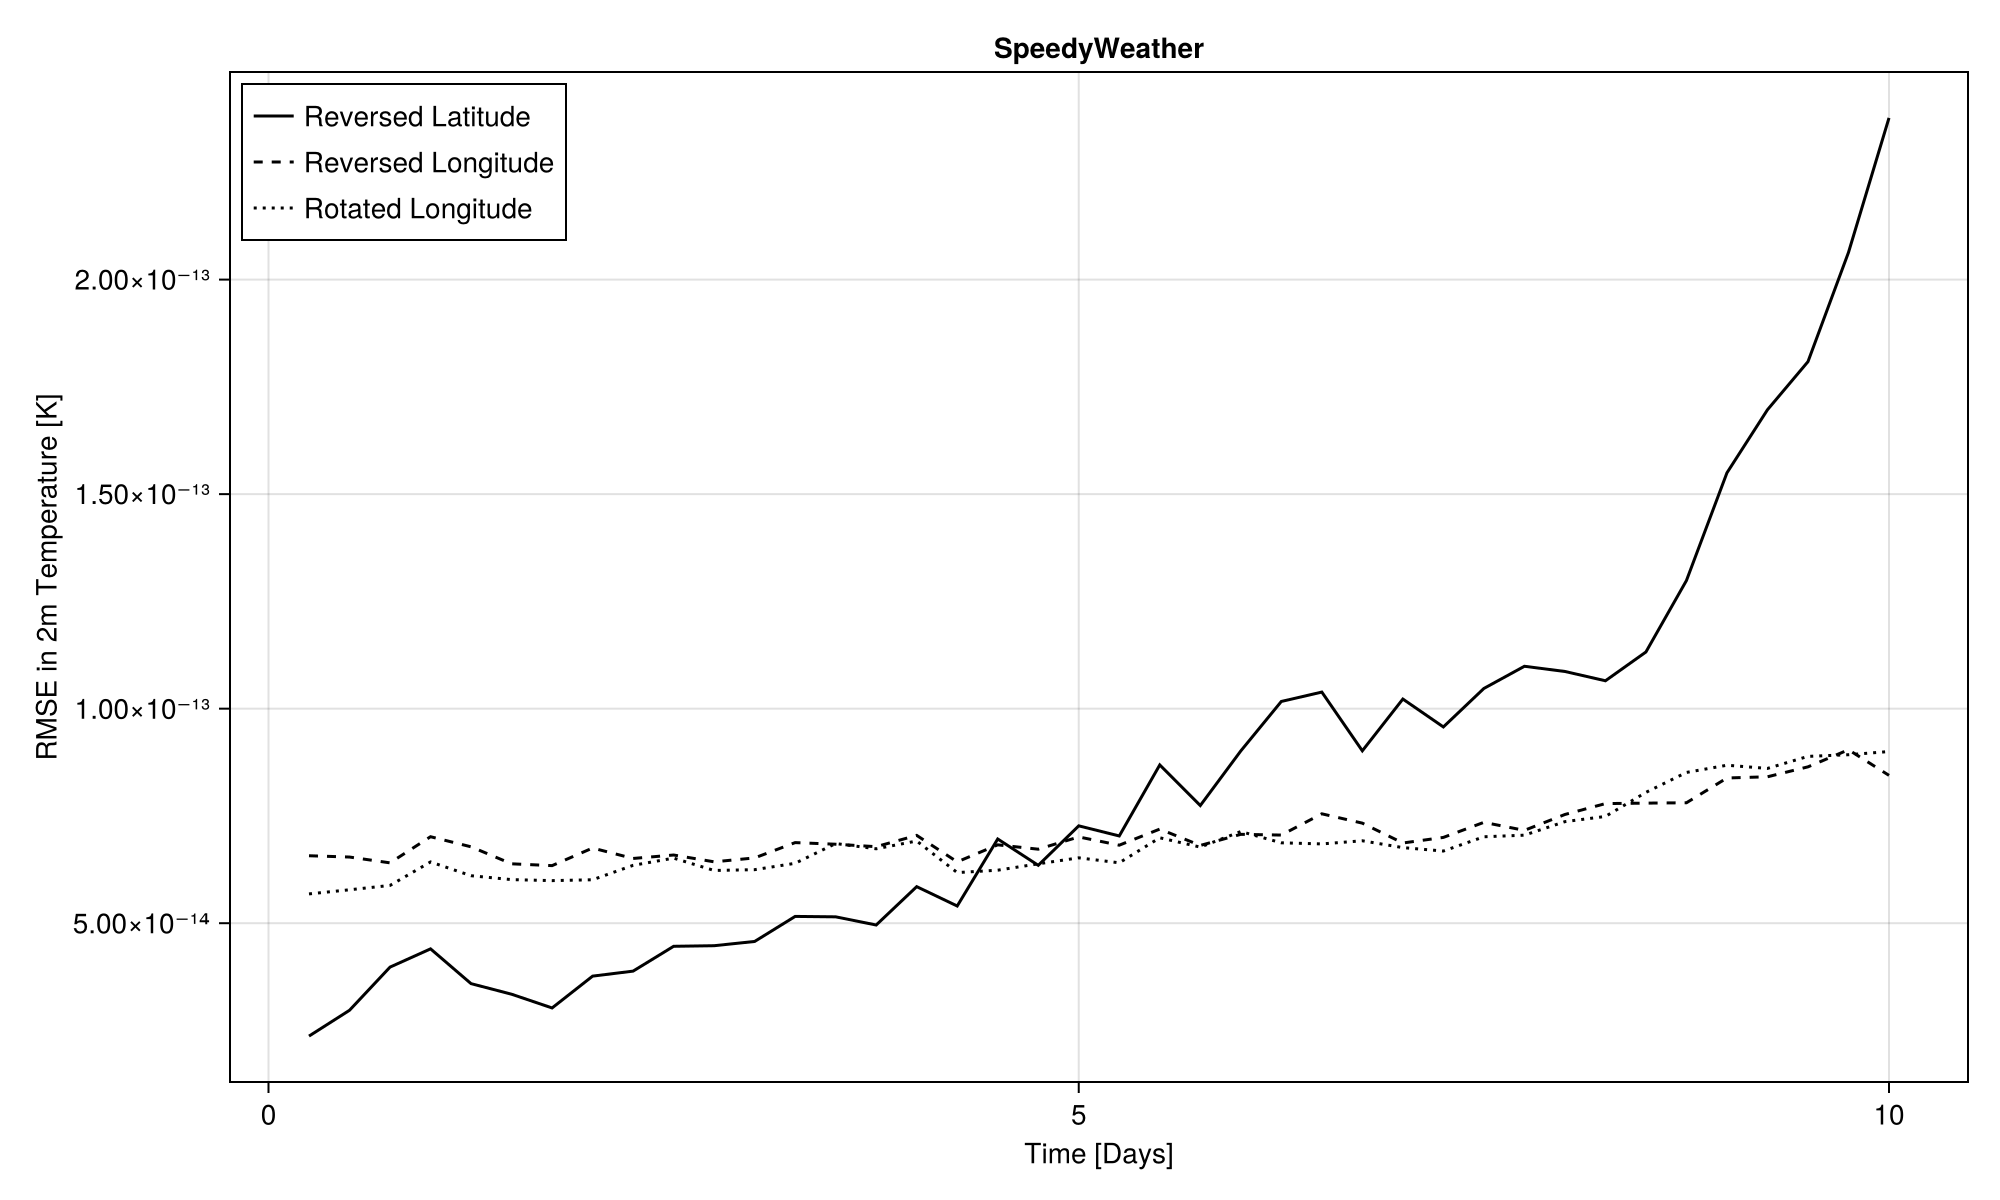

In [36]:
using NCDatasets, CairoMakie, Statistics

dir = SAVE_DIR  # defined in the config cell at the top of this notebook

files = [
    ("error_reverse_lat.nc",  "Reversed Latitude", :solid),
    ("error_reverse_lon.nc",  "Reversed Longitude", :dash),
    ("error_rotate_lon.nc",   "Rotated Longitude",  :dot),
]

time_days = TIMES_H ./ 24

fig = Figure(size=(1000, 600))
ax  = Axis(fig[1,1], xlabel="Time [Days]", ylabel="RMSE in 2m Temperature [K]",
           title="SpeedyWeather")

for (fname, label, ls) in files
    ds   = Dataset(joinpath(dir, fname))
    err  = ds["temperature_error"][:, :]   # gridpoint x time
    close(ds)
    rmse = vec(sqrt.(mean(abs2, err, dims=1)))
    lines!(ax, time_days, rmse, color=:black, linestyle=ls, label=label)
end

axislegend(ax, position=:lt)
fig

## Reproducing this notebook vs. reproducing the published figure

Re-running this notebook on a different machine reproduces the same **qualitative**
result -- errors at machine-epsilon level, confirming that SpeedyWeather preserves
these grid symmetries -- but not the same floating-point digits. At around 1e-13 K,
results depend on CPU architecture, thread count and the FFT/BLAS build, which
differ from machine to machine; pinning package versions does not change this. It
is a limit of cross-machine floating-point reproducibility, not a fault in the
model or the code.

Because the published figure needs to be reproducible exactly rather than only
qualitatively, this repository also includes:

- **`../data/SpeedyWeather/paper_original/`** -- the three error files from the run
  that produced the published figure, copied byte for byte, with checksums recorded
  in `../README.md`.
- **`reproduce_published_figure/plot_published_figure.ipynb`** -- a small
  Python notebook, with its own environment (see the README in that folder), that
  reads those files and reproduces `speedyweather_rmse_vs_leadtime.jpeg`.

In short: run **this** notebook to check that the SpeedyWeather pipeline works end
to end on your machine, and **`plot_published_figure.ipynb`** if you want the
exact figure published in the paper.